In [19]:
from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

#Leitura do Dataset
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

#Remocao dos dados desnecessarios
df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

#Ajuste do indice
df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index.freq = "MS"

df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

#Ajuste da nomeclatura das colunas para o prophet
df.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)

#A coluna "ds" é o indice, enquanto a coluna "y" é a que será utilizada para a previsão
df.columns = ["ds", "y", "y2", "y3", "y4", "y5"]

In [20]:
df.columns = ["ds", "y1", "y", "y3", "y4", "y5"]

In [21]:
m = Prophet(growth='flat',yearly_seasonality=11)

m.fit(df)

12:04:33 - cmdstanpy - INFO - Chain [1] start processing
12:04:33 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
future = m.make_future_dataframe(periods=48,freq='MS')

normal_forecast = m.predict(future)

<Axes: title={'center': 'Predições Empresa 1 - Prophet'}, xlabel='Data', ylabel='Consumo(KWh)'>

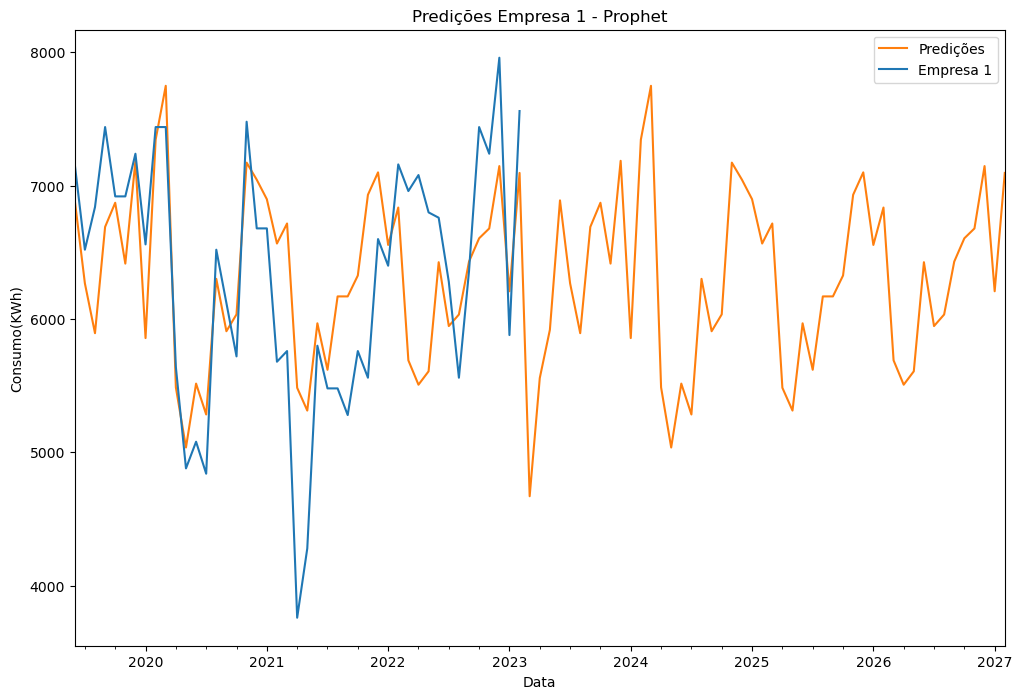

In [23]:
xlabel="Data"
ylabel="Consumo(KWh)"
title="Predições Empresa 1 - Prophet"

ax = normal_forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8), color="#ff7f0e")
df.plot(x='ds',y='y',label='Empresa 1',legend=True,ax=ax,color="#1f77b4",title=title,xlabel=xlabel,ylabel=ylabel)

In [24]:
# Lendo os dados
df_aug = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df_aug.drop(df_aug.iloc[:, 48:68], inplace=True, axis=1)
df_aug.drop("Nº Cliente", inplace=True, axis=1)
df_aug.drop("Cliente", inplace=True, axis=1)

df_aug = df_aug.head()

df_aug = df_aug.transpose()
df_aug = df_aug.rename(columns=df_aug.iloc[0])
df_aug.drop("UC", inplace=True, axis=0)
df_aug.dropna(inplace=True)

df_aug.index
dates = np.array(df_aug.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df_aug["idx"] = idx
df_aug.set_index("idx", inplace=True)
df_aug.index.freq = "MS"

df_aug = pd.concat([df_aug, df_aug])

new_index = pd.date_range(start=df_aug.index.min(), periods=len(df_aug), freq="MS")

df_aug.index = new_index

df_aug.reset_index(inplace=True)
df_aug = df_aug.rename(columns={"index": "DS"})

df_aug.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df_aug["y1"] = df_aug["y1"].astype(int)
df_aug["y2"] = df_aug["y2"].astype(int)
df_aug["y3"] = df_aug["y3"].astype(int)
df_aug["y4"] = df_aug["y4"].astype(int)
df_aug["y5"] = df_aug["y5"].astype(int)

df_aug.columns = ["ds", "y1", "y", "y3", "y4", "y5"]

In [25]:
m = Prophet(growth='flat',yearly_seasonality=160)

m.fit(df_aug)

future = m.make_future_dataframe(periods=48,freq='MS')

augment_forecast = m.predict(future)

12:04:33 - cmdstanpy - INFO - Chain [1] start processing
12:04:35 - cmdstanpy - INFO - Chain [1] done processing


<Axes: title={'center': 'Predições Empresa 1 - Prophet Augment'}, xlabel='Data', ylabel='Consumo(KWh)'>

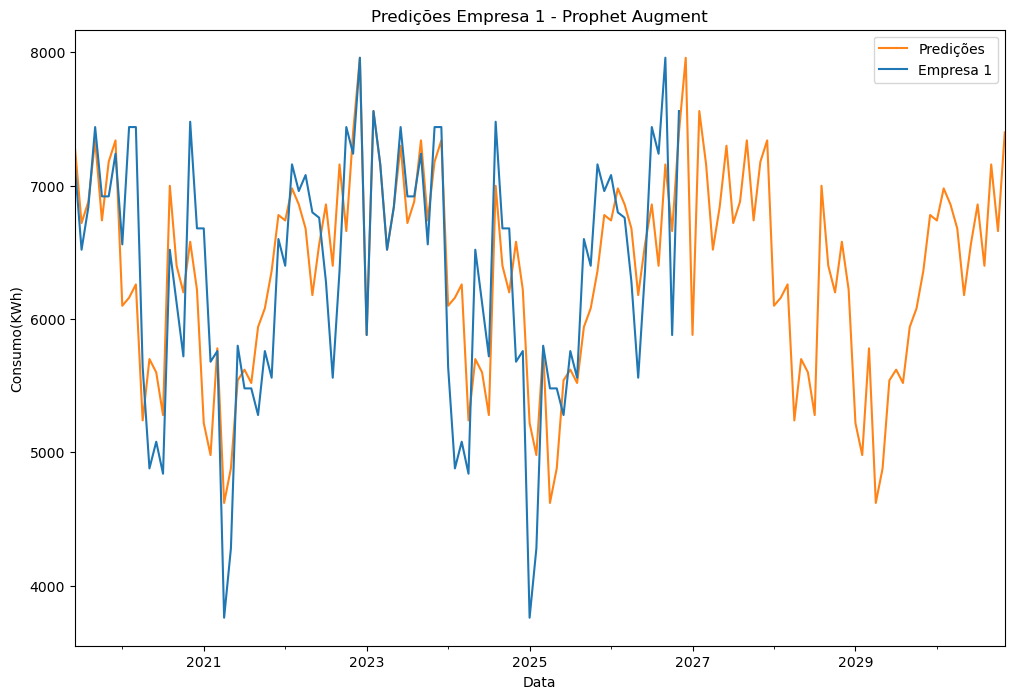

In [26]:
ax = augment_forecast.plot(x='ds', y='yhat', label='Predições',legend=True, figsize=(12,8),color="#ff8316",title="Predições Empresa 1 - Prophet Augment",ylabel="Consumo(KWh)")
df_aug.plot(x='ds',y='y',label='Empresa 1',legend=True,ax=ax,xlabel="Data")

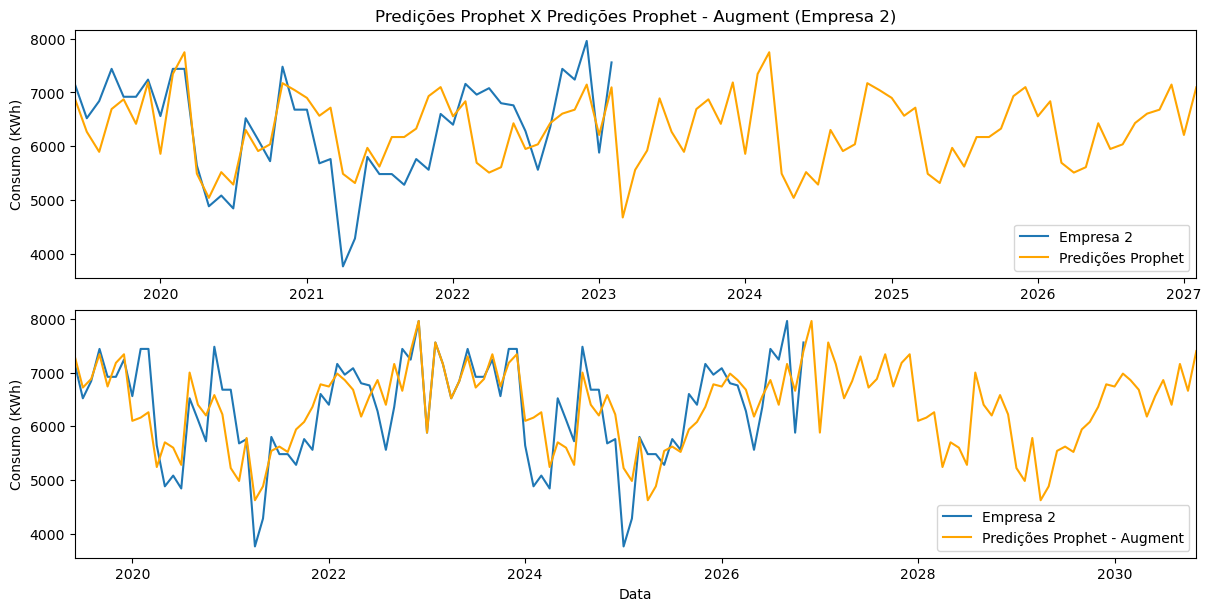

In [35]:
title = "Predições Prophet X Predições Prophet - Augment (Empresa 2)"
ylabel = "Consumo (KWh)"
xlabel = "Data"
fig, (ax1, ax2) = plt.subplots(2, 1, layout='constrained',figsize=(12,6))
#ax1 = df[3001449459].plot(label="MD Predial - 1")
#ax2 = df[3011504476].plot(label="MD Predial - 2")
ax1.plot(df['ds'],df['y'],label="Empresa 2")
ax1.plot(normal_forecast['ds'],normal_forecast['yhat'],label="Predições Prophet",color='orange')
ax1.set(ylabel=ylabel,title=title)
ax1.legend(loc="lower right")
ax1.autoscale(axis="x", tight=True)
ax2.plot(df_aug['ds'],df_aug['y'],label="Empresa 2")
ax2.plot(augment_forecast['ds'],augment_forecast['yhat'],label="Predições Prophet - Augment",color='orange')
ax2.set(xlabel=xlabel, ylabel=ylabel)
ax2.legend(loc="lower right")
ax2.autoscale(axis="x", tight=True)

plt.savefig("prophet_empr2_comp_graph.png")

In [32]:
normal_forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,6423.2026,6032.827533,7730.222113,6423.2026,6423.2026,466.913740,466.913740,466.913740,466.913740,466.913740,466.913740,0.0,0.0,0.0,6890.116340
1,2019-07-01,6423.2026,5351.867047,7099.103899,6423.2026,6423.2026,-155.443356,-155.443356,-155.443356,-155.443356,-155.443356,-155.443356,0.0,0.0,0.0,6267.759244
2,2019-08-01,6423.2026,5025.286889,6736.333991,6423.2026,6423.2026,-529.143767,-529.143767,-529.143767,-529.143767,-529.143767,-529.143767,0.0,0.0,0.0,5894.058833
3,2019-09-01,6423.2026,5828.364394,7508.522456,6423.2026,6423.2026,268.016067,268.016067,268.016067,268.016067,268.016067,268.016067,0.0,0.0,0.0,6691.218667
4,2019-10-01,6423.2026,5996.532355,7771.714688,6423.2026,6423.2026,449.014712,449.014712,449.014712,449.014712,449.014712,449.014712,0.0,0.0,0.0,6872.217312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2026-10-01,6423.2026,5817.737145,7569.948315,6423.2026,6423.2026,182.462212,182.462212,182.462212,182.462212,182.462212,182.462212,0.0,0.0,0.0,6605.664812
89,2026-11-01,6423.2026,5800.810624,7569.416763,6423.2026,6423.2026,256.292029,256.292029,256.292029,256.292029,256.292029,256.292029,0.0,0.0,0.0,6679.494629
90,2026-12-01,6423.2026,6234.603074,7997.907867,6423.2026,6423.2026,724.097723,724.097723,724.097723,724.097723,724.097723,724.097723,0.0,0.0,0.0,7147.300323
91,2027-01-01,6423.2026,5305.549308,7097.224683,6423.2026,6423.2026,-214.742599,-214.742599,-214.742599,-214.742599,-214.742599,-214.742599,0.0,0.0,0.0,6208.460001
